In [ ]:
from collections.abc import Callable, Iterable
from typing import Optional
import torch
import math
class SGD(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3):
        if lr < 0:
            raise ValueError(f"Invalid learning rate: {lr}")
        defaults = {"lr": lr}
        super().__init__(params, defaults)
    def step(self, closure: Optional[Callable] = None):
        loss = None if closure is None else closure()
        for group in self.param_groups:
            lr = group["lr"]  # Get the learning rate.
            for p in group["params"]:
                if p.grad is None:
                    continue
                state = self.state[p]  # Get state associated with p.
                t = state.get(
                    "t", 0
                )  # Get iteration number from the state, or initial value.
                grad = p.grad.data  # Get the gradient of loss with respect to p.
                p.data -= lr / math.sqrt(
                    t + 1) * grad  # Update weight tensor in-place.
                state["t"] = t + 1  # Increment iteration number.
        return loss

LR 10.0, Iteration 0: 23.85629653930664
LR 10.0, Iteration 1: 15.268031120300293
LR 10.0, Iteration 2: 11.254939079284668
LR 10.0, Iteration 3: 8.80578899383545
LR 10.0, Iteration 4: 7.132688522338867
LR 10.0, Iteration 5: 5.913815975189209
LR 10.0, Iteration 6: 4.98751974105835
LR 10.0, Iteration 7: 4.261977672576904
LR 10.0, Iteration 8: 3.6805527210235596
LR 10.0, Iteration 9: 3.2061703205108643
LR 100.0, Iteration 0: 23.85629653930664
LR 100.0, Iteration 1: 23.856294631958008
LR 100.0, Iteration 2: 4.093092441558838
LR 100.0, Iteration 3: 0.09795693308115005
LR 100.0, Iteration 4: 1.3885593745818997e-16
LR 100.0, Iteration 5: 1.5476355907398964e-18
LR 100.0, Iteration 6: 5.211433991362129e-20
LR 100.0, Iteration 7: 3.104486992939115e-21
LR 100.0, Iteration 8: 2.6632295045592e-22
LR 100.0, Iteration 9: 2.959144104317575e-23
LR 1000.0, Iteration 0: 23.85629653930664
LR 1000.0, Iteration 1: 8612.1220703125
LR 1000.0, Iteration 2: 1487449.125
LR 1000.0, Iteration 3: 165462816.0
LR 1000

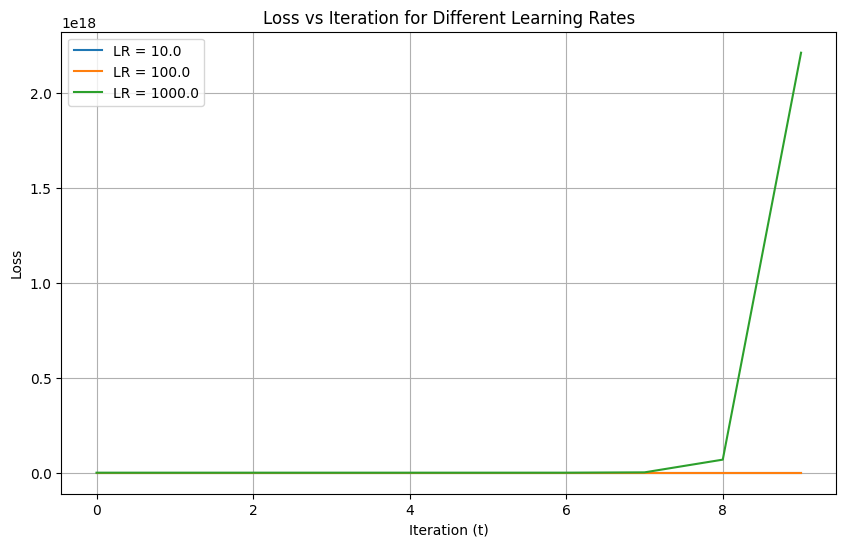

In [ ]:
import matplotlib.pyplot as plt
# Compare different learning rates: 1e1, 1e2, and 1e3
learning_rates = [1e1, 1e2, 1e3]
plt.figure(figsize=(10, 6))
for lr in learning_rates:
    # Store loss values for plotting
    losses = []
    torch.manual_seed(20)
    weights = torch.nn.Parameter(5 * torch.randn((10, 10)))
    opt = SGD([weights], lr=lr)
    for t in range(10):  # Only 10 iterations
        opt.zero_grad()  # Reset the gradients for all learnable parameters.
        loss = (weights**2).mean()  # Compute a scalar loss value.
        losses.append(loss.cpu().item())
        print(f"LR {lr}, Iteration {t}: {loss.cpu().item()}")
        loss.backward()  # Run backward pass, which computes gradients.
        opt.step()  # Run optimizer step.
    # Plot loss vs iteration for this learning rate
    plt.plot(range(10), losses, label=f'LR = {lr}')
plt.xlabel('Iteration (t)')
plt.ylabel('Loss')
plt.title('Loss vs Iteration for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()